In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import add_dummy_feature, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [2]:
pd.set_option('display.max_columns', 200)

In [3]:
df = pd.read_csv('./datasets/Social_Network_Ads.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df = df.drop('User ID', axis=1)

In [6]:
df.sample(5)

,Gender,Age,EstimatedSalary,Purchased
28,Male,29,43000,0
285,Female,37,93000,1
347,Female,54,108000,1
20,Male,45,22000,1
366,Female,58,47000,1


In [7]:
X = np.array(df['EstimatedSalary'].astype('float')).reshape(-1, 1)
y = np.array(df['Purchased']).reshape(-1, 1)

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

In [10]:
X_train_d = add_dummy_feature(X_train)
X_test_d  = add_dummy_feature(X_test)

In [11]:
class MyLogisticRegression:
    def __init__(self, eta=0.1, num_epochs=1000):
        self.eta = eta
        self.num_epochs = num_epochs
        self.theta_ = None
    
    def fit(self, X, y):
        np.random.seed(42)
        m, n = X.shape
        self.theta_ = np.random.rand(n, 1) * 0.01
        self.loss_history_ = []

        for _ in range(self.num_epochs):
            z = X @ self.theta_
            predictions = self.__sigmoid(z)

            gradients = (1 / m) * (X.T @ (predictions - y))
            self.theta_ = self.theta_ - self.eta * gradients

            p = np.clip(predictions, 1e-9, 1 - 1e-9)
            loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
            self.loss_history_.append(loss)
        
        self.intercept_ = self.theta_[0, 0]
        self.coef_ = self.theta_[1:, :].flatten()
        return self
    
    def better_thresholds(self, X_test, y_test):
        thresholds = np.linspace(0.1, 0.9, 50)
        probas = self.predict_proba(X_test)

        f1_scores = []
        for t in thresholds:
            y_pred_t = (probas >= t).astype(int)
            TP = np.sum((y_test.flatten() == 1) & (y_pred_t == 1))
            FP = np.sum((y_test.flatten() == 0) & (y_pred_t == 1))
            FN = np.sum((y_test.flatten() == 1) & (y_pred_t == 0))
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
            recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            f1_scores.append(f1)

        return thresholds[np.argmax(f1_scores)]
    
    def predict_proba(self, X):
        return self.__sigmoid(X @ self.theta_).flatten()
    
    def predict(self, X, threshold):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def __sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))

In [12]:
model = MyLogisticRegression(eta=0.1, num_epochs=1000)

model.fit(X_train_d, y_train)

In [13]:
threshold = model.better_thresholds(X_test_d, y_test)
y_pred = model.predict(X_test_d, threshold)

In [14]:
sk = LogisticRegression()

sk.fit(X_train_d, y_train.ravel())
y_pred_sk = sk.predict(X_test_d)

In [15]:
print(f"Manual  \nintercept: {model.intercept_:.4f} \t coef: {model.coef_} \t score: {accuracy_score(y_test, y_pred)}")
print(f"sklearn \nintercept: {sk.intercept_[0]:.4f} \t coef: {sk.coef_[:, 1]} \t score: {accuracy_score(y_test, y_pred_sk)}")

Manual  
intercept: -0.6563 	 coef: [0.86311868] 	 score: 0.7875
sklearn 
intercept: -0.6591 	 coef: [0.8478697] 	 score: 0.7375


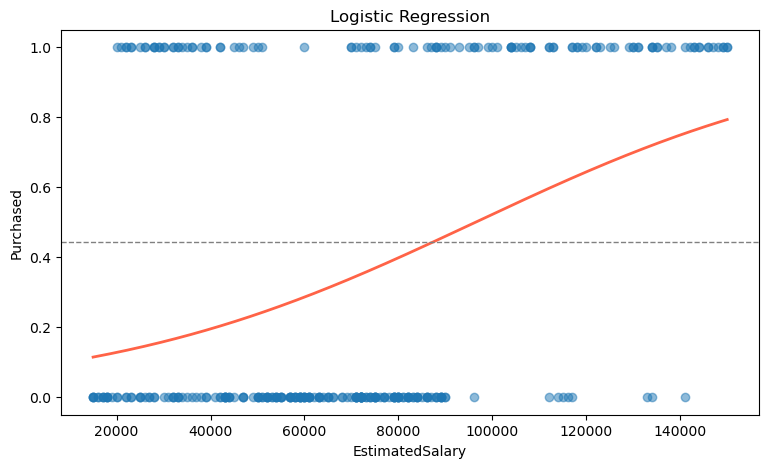

In [16]:
x_norm   = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
x_dummy  = add_dummy_feature(x_norm)
x_salary = scaler.inverse_transform(x_norm).flatten()

prob  = model.predict_proba(x_dummy)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_salary, prob,  color='tomato',lw=2)
ax.scatter(
    scaler.inverse_transform(X_train).flatten(), y_train.flatten(), zorder=3, alpha=0.5
)
ax.axhline(threshold, color='gray', linestyle='--', linewidth=1)

ax.set_xlabel('EstimatedSalary')
ax.set_ylabel('Purchased')
ax.set_title('Logistic Regression')
plt.show()

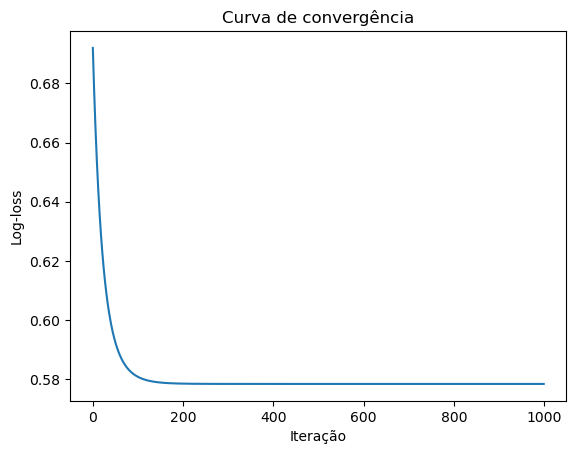

In [17]:
plt.plot(model.loss_history_)
plt.xlabel('Iteração')
plt.ylabel('Log-loss')
plt.title('Curva de convergência')
plt.show()